## GANSim tutorial for 2D meandering-channel reservoir modelling

**Audience:** reservoir engineers, geoscientists, and researchers who are more interested in practical reservoir applications than machine-learning implementation details.

**Teaching style:** this notebook uses short, application-level commands. Most TensorFlow and array-shape details are hidden in `gansim_pointbar_tutorial_helpers.py`.

By the end of this code session, participants should understand how GANSim can be used to:

1. generate multiple geologically realistic reservoir realizations;
2. condition geomodels to sparse well facies data, facies probability maps, and global geological features;
3. model reservoir areas of different sizes; and
4. generate nonstationary field-scale models using spatially varying conditioning inputs.


### Practical framing: knowns and unknowns

In a real reservoir study, we rarely know the full facies distribution. We usually have:

- **Known data:** well facies interpretation, seismic-derived probability maps, regional depositional concepts, global feature estimates, and sometimes production/history data.
- **Unknowns:** the complete inter-well facies distribution and uncertainty in connected sand bodies, mud drapes, channel fills, and lateral-accretion/point-bar deposits.

Here, GANSim is used as a fast geomodelling engine: it generates many realistic candidate facies models that honor available data while still representing geological uncertainty.

## 0. Download related data and set up libraries

**Downloads a GenAIGeomodeling folder from Google Drive. It contains all notebooks, helper codes, trained generators, and data.**

In [2]:
# install the gdown package which can download files from Google Drive.
!pip install -U gdown
import gdown

# Download GenAIGeomodeling folder.
folder_id = "1ny-5zhdjAnw_EI7jONOlQa4qCVUVCepQ"
gdown.download_folder(f"https://drive.google.com/drive/folders/{folder_id}", use_cookies=True)

Retrieving folder contents


Retrieving folder 1RuiW6eaY00Lh_PmAf0CMniC7QiHiHvLb Data
Retrieving folder 1Tsr5slgSSb-JrA3eul-zm_9KPggF5u-G GANSim_2DPointbar_Data_Model
Retrieving folder 1oH3rd9Ze2lNU2MnDmHFHL2Q5wqALB3le PreparedDataset
Retrieving folder 15g9q13H2FeKIaNk-hBXUJruH20zmaCre TestData
Processing file 1Y1oRVJQKWA1jPfMkL3bcdBV398v_AqSm TestData-1r02.tfrecords
Processing file 1PIbDfrleokeygJCJqGAfVav3ahgPwWc9 TestData-1r03.tfrecords
Processing file 1yQCPrL3gkLzYhl3USn_NZgvPhVw_kX6P TestData-1r04.tfrecords
Processing file 13I4Cm99XfayMbZYAnNYu6icmEuWO14YN TestData-1r05.tfrecords
Processing file 18o9_c7BfTXBEPsiG6rpVWogmMOxylZTw TestData-1r06.tfrecords
Processing file 1QEdv6Jd4lLjZPUATiG2gFojj3f2zsMfP TestData-2probimages.tfrecords
Processing file 1kO92bwP5Y08ScTfhaep60f8w4IQ2kfJC TestData-3wellfacies.tfrecords
Processing file 1KoNSrr7Agz6JFNgcPGTBgosVSvL_gwAS TestData-4rxx.labels
Retrieving folder 159MCQ9VhPDYAgOlRKA_jCSOKEnZDksTO SNESIM
Processing file 16ic1mMX91Ss66Az387VEiTn-n7ktMdD- pointbar_cond_faciesm

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1Y1oRVJQKWA1jPfMkL3bcdBV398v_AqSm
To: /content/GenAIGeomodeling/Data/GANSim_2DPointbar_Data_Model/PreparedDataset/TestData/TestData-1r02.tfrecords
100%|██████████| 118k/118k [00:00<00:00, 47.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1PIbDfrleokeygJCJqGAfVav3ahgPwWc9
To: /content/GenAIGeomodeling/Data/GANSim_2DPointbar_Data_Model/PreparedDataset/TestData/TestData-1r03.tfrecords
100%|██████████| 203k/203k [00:00<00:00, 61.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1yQCPrL3gkLzYhl3USn_NZgvPhVw_kX6P
To: /content/GenAIGeomodeling/Data/GANSim_2DPointbar_Data_Model/PreparedDataset/TestData/TestData-1r04.tfrecords
100%|██████████| 555k/555k [00:00<00:00, 102MB/s]
Downloading...
From: https://drive.google.com/uc?id=13I4Cm99XfayMbZYAnNYu6icmEuWO14YN
To: /content/GenAIGeomodeling/Data/GANSim_2DPointbar_Data_Mo

['/content/GenAIGeomodeling/Data/GANSim_2DPointbar_Data_Model/PreparedDataset/TestData/TestData-1r02.tfrecords',
 '/content/GenAIGeomodeling/Data/GANSim_2DPointbar_Data_Model/PreparedDataset/TestData/TestData-1r03.tfrecords',
 '/content/GenAIGeomodeling/Data/GANSim_2DPointbar_Data_Model/PreparedDataset/TestData/TestData-1r04.tfrecords',
 '/content/GenAIGeomodeling/Data/GANSim_2DPointbar_Data_Model/PreparedDataset/TestData/TestData-1r05.tfrecords',
 '/content/GenAIGeomodeling/Data/GANSim_2DPointbar_Data_Model/PreparedDataset/TestData/TestData-1r06.tfrecords',
 '/content/GenAIGeomodeling/Data/GANSim_2DPointbar_Data_Model/PreparedDataset/TestData/TestData-2probimages.tfrecords',
 '/content/GenAIGeomodeling/Data/GANSim_2DPointbar_Data_Model/PreparedDataset/TestData/TestData-3wellfacies.tfrecords',
 '/content/GenAIGeomodeling/Data/GANSim_2DPointbar_Data_Model/PreparedDataset/TestData/TestData-4rxx.labels',
 '/content/GenAIGeomodeling/Data/GANSim_2DPointbar_Data_Model/SNESIM/pointbar_cond_fa

**Load related libraries, helper functions, and code paths.**


In [2]:
import sys
import pickle
import numpy as np
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
tf.disable_eager_execution()
import PIL.Image
%matplotlib inline
import matplotlib.pyplot as plt

code_path = r'/content/GenAIGeomodeling/Notebooks/GANSim_2DPointbar_Codes/GANSimModel/'
sys.path.append(code_path)
# Import helper functions
from gansim_pointbar_tutorial_helpers import *

print("-"*60)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Instructions for updating:
non-resource variables are not supported in the long term


------------------------------------------------------------
Num GPUs Available:  0


## 1. Import trained GANSim generator for meandering channel reservoir (2D)

The pretrained generator has already learned meandering-channel / point-bar reservoir patterns from training images.


In [3]:
# path of the generator
GANSim_dir = r'/content/GenAIGeomodeling/Data/GANSim_2DPointbar_Data_Model/TrainedModels/'
GANSim_name = 'network-snapshot-026560.pkl'

G_base = import_generator(GANSim_dir, GANSim_name)

Instructions for updating:
The TensorFlow Distributions library has moved to TensorFlow Probability (https://github.com/tensorflow/probability). You should update all references to use `tfp.distributions` instead of `tf.distributions`.
Instructions for updating:
The TensorFlow Distributions library has moved to TensorFlow Probability (https://github.com/tensorflow/probability). You should update all references to use `tfp.distributions` instead of `tf.distributions`.


Loading pretrained generator from:
  /content/GenAIGeomodeling/Data/GANSim_2DPointbar_Data_Model/TrainedModels/network-snapshot-026560.pkl
Pretrained generator loaded successfully.
Input shapes: [[Dimension(None), Dimension(8), Dimension(4), Dimension(4)], [Dimension(None), Dimension(2), Dimension(64), Dimension(64)], [Dimension(None), Dimension(2), Dimension(64), Dimension(64)], [Dimension(None), Dimension(3), Dimension(64), Dimension(64)]]
Output shapes: [[Dimension(None), Dimension(4), Dimension(64), Dimension(64)]]


**Inputs to the generator:**

- Random latent maps, similar to random seeds in traditional geomodelling.

- Two global geological features, either as two values or spatially varying maps:
  pointbar development index and floodplain proportion.

- Well facies data, including a well-location indicator map and a well-facies map.

- Three facies probability maps for mud drape, channel fill, and lateral accretion.

**Output from the generator: facies indicator maps for floodplain/background, mud drape, channel fill, and lateral accretion deposits.**

**The generator can be used for reservoir areas of different sizes, but the cell size is fixed at 10 m × 10 m.**


## 2. Conditional geomodelling for a smaller reservoir (64 × 64 cells)

Assume we have a small meandering-channel reservoir area of 640 m × 640 m, represented by `64 × 64` cells.

The first step is to collect conditioning data. Different types of conditioning data should be mutually consistent. For demonstration, we use a synthetic geomodel as the “truth” and build different but consistent conditioning data from it.


### 2.1 Building conditioning data from a synthetic "truth"

Conditioning data include:

- sparse **well facies** control points;
- smoothed/noisy **facies probability maps**; and
- **global geological features**, including pointbar development index and floodplain proportion.

In a real project, these conditioning data would come from well interpretation, seismic/geophysical analysis, and geological concepts.


In [4]:
data_dir_test = "/content/GenAIGeomodeling/Data/GANSim_2DPointbar_Data_Model/PreparedDataset/"
test_data = load_test_data(data_dir=data_dir_test, tfrecord_dir="TestData", minibatch_size=300)

# Synthetic facies maps as the "truth".
facies_test = test_data["facies"]

# Global geological features.
# pointbar development index: original value range 0.2-2.0
# floodplain proportion: original value range 0.5-0.82
pointbar_dev_test = test_data["pointbar_dev"]
floodplain_prop_test = test_data["floodplain_prop"]

# Facies probability maps for mud drape, channel fill, and lateral accretion.
probimgs_test = test_data["probs"]

# Well conditioning data: well location indicator and well facies code.
wellfacies_out = test_data["wells"]

print("-" * 60)
print("Loaded test data shapes:")
print(f"  facies_test:          {facies_test.shape}")
print(f"  pointbar_dev_test:    {pointbar_dev_test.shape}")
print(f"  floodplain_prop_test: {floodplain_prop_test.shape}")
print(f"  probimgs_test:        {probimgs_test.shape}")
print(f"  wellfacies_out:       {wellfacies_out.shape}")


Instructions for updating:
Use eager execution and: 
`tf.data.TFRecordDataset(path)`


Streaming data using dataset.TFRecordDataset...


Instructions for updating:
Use `tf.compat.v1.data.get_output_types(dataset)`.
Instructions for updating:
Use `tf.compat.v1.data.get_output_shapes(dataset)`.
Instructions for updating:
Use `tf.compat.v1.data.get_output_types(iterator)`.
Instructions for updating:
Use `tf.compat.v1.data.get_output_shapes(iterator)`.
Instructions for updating:
Use `tf.compat.v1.data.get_output_classes(iterator)`.


Dataset shape = [1, 64, 64]
Dynamic range = [0, 2]
Label size    = 0
Test data loaded.
  facies: (300, 1, 64, 64)
  global_features: (300, 2)
  pointbar_dev: (300,)
  floodplain_prop: (300,)
  probs: (300, 3, 64, 64)
  wells: (300, 2, 64, 64)
------------------------------------------------------------
Loaded test data shapes:
  facies_test:          (300, 1, 64, 64)
  pointbar_dev_test:    (300,)
  floodplain_prop_test: (300,)
  probimgs_test:        (300, 3, 64, 64)
  wellfacies_out:       (300, 2, 64, 64)


**300 groups of conditioning data are loaded. For illustration, we choose one sample as an example. Here we use `test_num = 8`.**


In [5]:
test_num = 218

facies_truth_64 = facies_test[test_num]
wellfacies_64 = wellfacies_out[test_num]
probs_64 = probimgs_test[test_num]

print("Conditioning data shapes for the selected sample:")
print(f"  facies_truth_64: {facies_truth_64.shape}")
print(f"  wellfacies_64:   {wellfacies_64.shape}")
print(f"  probs_64:        {probs_64.shape}")


Conditioning data shapes for the selected sample:
  facies_truth_64: (1, 64, 64)
  wellfacies_64:   (2, 64, 64)
  probs_64:        (3, 64, 64)


Plot the truth facies map and the corresponding conditioning data.


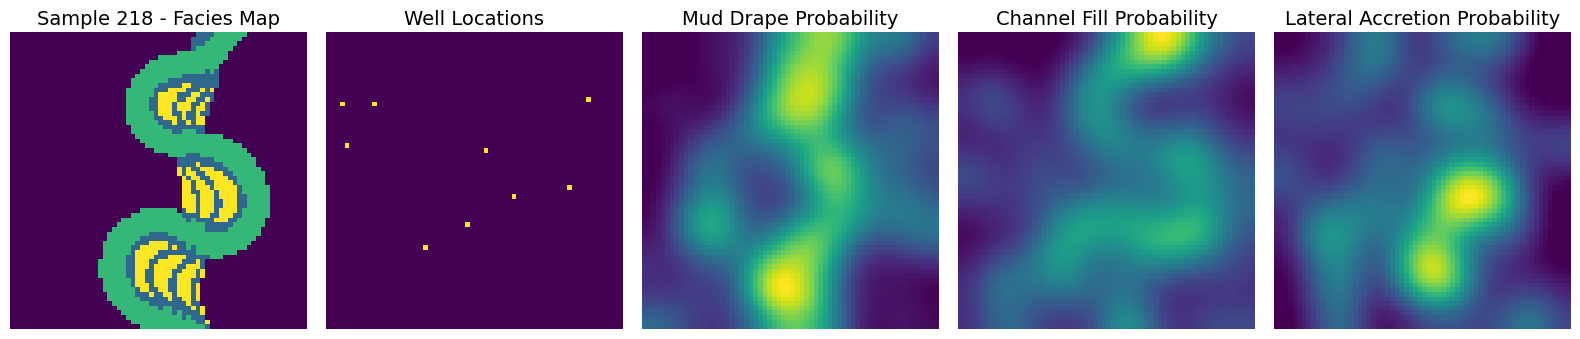

In [6]:
plt.rcParams.update({'font.size': 13})

fig, axs = plt.subplots(1, 5, figsize=(16, 4))

axs[0].imshow(facies_truth_64[0].astype(np.float32))
axs[0].set_title(f"Sample {test_num} - Facies Map", fontsize=14)
axs[0].axis('off')

axs[1].imshow(wellfacies_64[0].astype(np.float32))
axs[1].set_title("Well Locations", fontsize=14)
axs[1].axis('off')

axs[2].imshow(probs_64[0].astype(np.float32), cmap='viridis')
axs[2].set_title("Mud Drape Probability", fontsize=14)
axs[2].axis('off')

axs[3].imshow(probs_64[1].astype(np.float32), cmap='viridis')
axs[3].set_title("Channel Fill Probability", fontsize=14)
axs[3].axis('off')

axs[4].imshow(probs_64[2].astype(np.float32), cmap='viridis')
axs[4].set_title("Lateral Accretion Probability", fontsize=14)
axs[4].axis('off')

plt.tight_layout()
plt.show()


**In practice, we may only know a range for global features. Thus, make a range for both features.**

In [7]:
pointbar_dev_64 = pointbar_dev_test[test_num]      # mean value
pointbar_dev_var = 0.10                            # uncertainty/std for pointbar development index

floodplain_prop_64 = floodplain_prop_test[test_num]  # mean value
floodplain_prop_var = 0.02                           # uncertainty/std for floodplain proportion

print("Conditioning global features:")
print(f"  Pointbar development index mean: {pointbar_dev_64:.3f}")
print(f"    Uncertainty std: {pointbar_dev_var:.3f}")
print(f"  Floodplain proportion mean: {floodplain_prop_64:.3f}")
print(f"    Uncertainty std: {floodplain_prop_var:.3f}")


Conditioning global features:
  Pointbar development index mean: 0.826
    Uncertainty std: 0.100
  Floodplain proportion mean: 0.687
    Uncertainty std: 0.020


### 2.2 Conditional modelling with pretrained generator and evaluation of results

#### (1) Set up sizes for the generator

In [8]:
G_64 = build_generator_for_reservoir(G_base, nx = 64, ny = 64, network_name = "Gs_for_64x64")

Generator rebuilt for reservoir size.
  Reservoir size: 64 x 64
  Input shapes: [[Dimension(None), Dimension(8), Dimension(4), Dimension(4)], [Dimension(None), Dimension(2), Dimension(64), Dimension(64)], [Dimension(None), Dimension(2), Dimension(64), Dimension(64)], [Dimension(None), Dimension(3), Dimension(64), Dimension(64)]]
  Output shapes: [[Dimension(None), Dimension(4), Dimension(64), Dimension(64)]]


#### (2) Geomodelling

In [10]:
real_num = 100  # Number of realizations to simulate

# Randomly sample global features using Gaussian distributions.
pointbar_dev_samples = np.random.normal(loc=pointbar_dev_64, scale=pointbar_dev_var, size=real_num)
floodplain_prop_samples = np.random.normal(loc=floodplain_prop_64, scale=floodplain_prop_var, size=real_num)
# Stack sampled global features. Shape: [real_num, 2]
features_sampled_64 = np.stack([pointbar_dev_samples, floodplain_prop_samples], axis=1).astype(np.float32)

# Generate facies indicator maps using the trained generator.
# -??----------------------------------------------
# Hint: run_gen_model(G=Generator, realization_number=realization_num, wells=wellfacies,
#                                        probs=probs, global_features=features, seed=seeds)
gen_model_indicators_64 = run_gen_model(G=G_64, realization_number=real_num, wells=wellfacies_64,
                                        probs=probs_64, global_features=features_sampled_64, seed=160)
# -??----------------------------------------------

# Convert facies indicators into facies-code models.
gen_models_64 = np.expand_dims(np.argmax(gen_model_indicators_64, axis=1), axis=1)


**Visualize different realizations and evaluate conditioning to input probability maps**

Plot random realizations and frequency maps for mud drape, channel fill, and lateral accretion

In [11]:
# Calculate frequency maps for different facies types.
gen_model_freq_md = np.average(gen_model_indicators_64[:, 1], axis=0)
gen_model_freq_cf = np.average(gen_model_indicators_64[:, 2], axis=0)
gen_model_freq_la = np.average(gen_model_indicators_64[:, 3], axis=0)


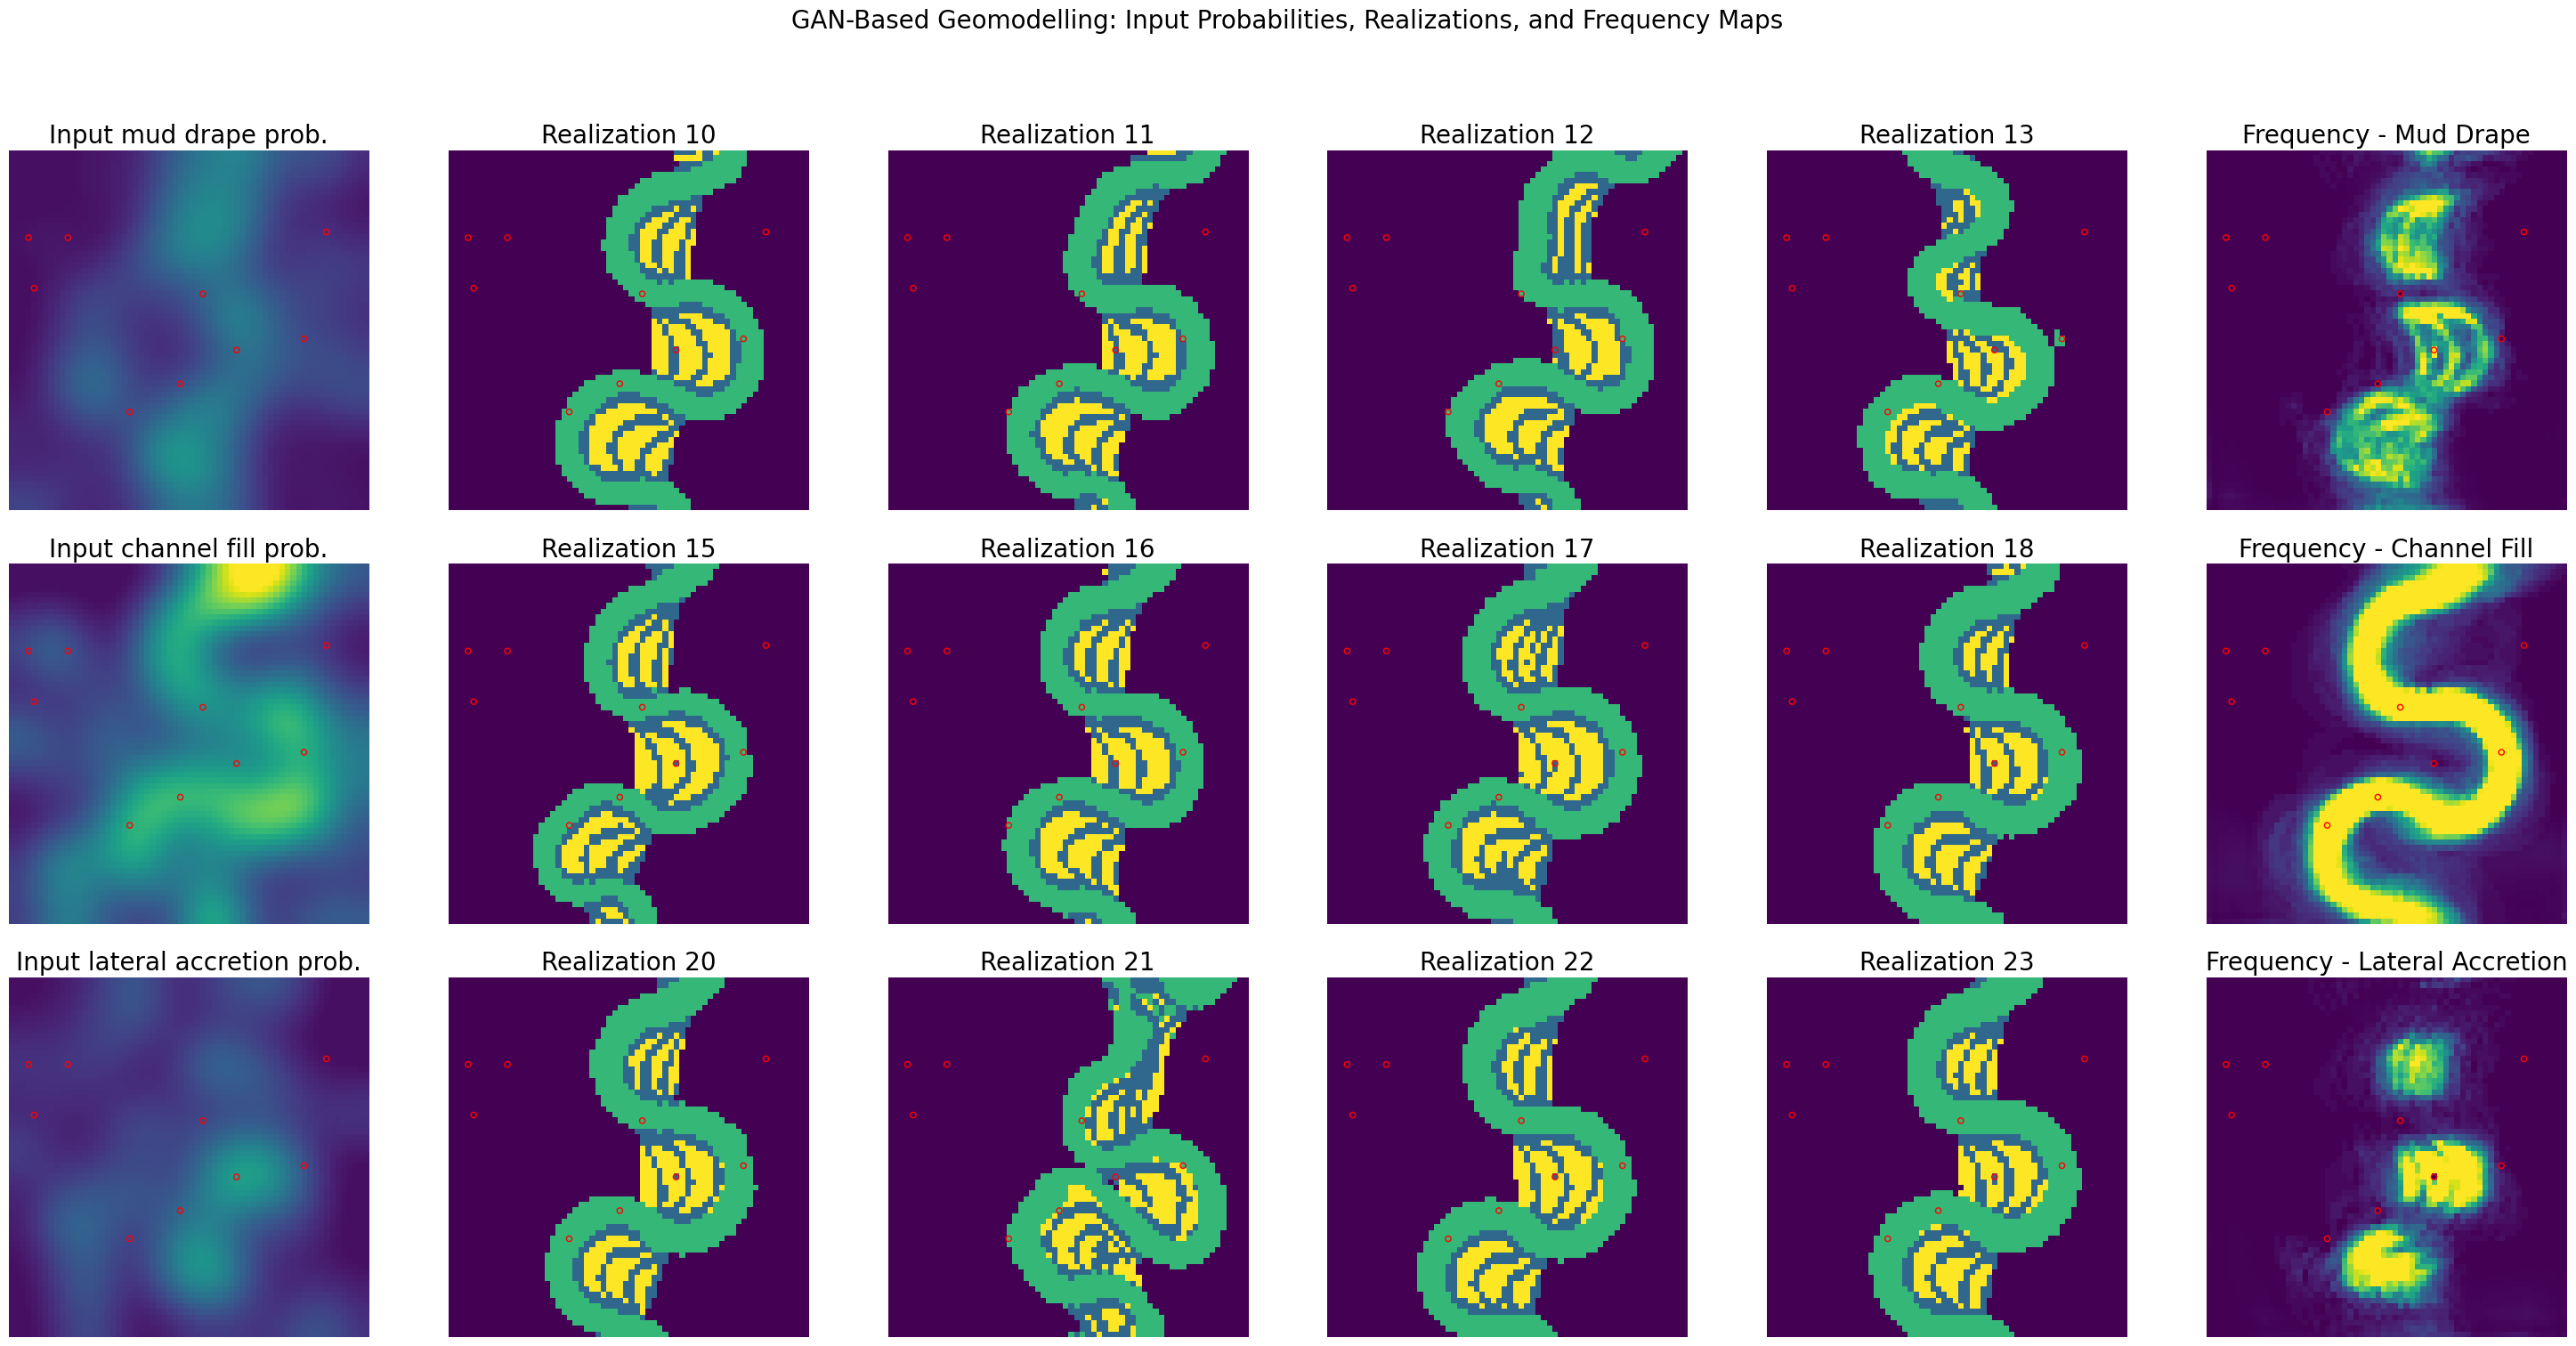

In [12]:
plt.rcParams.update({'font.size': 25})

fig, ax = plt.subplots(3, 6, sharex='col', sharey='row')
fig.set_size_inches(30, 15, forward=True)

# Plot input probability maps.
ax[0, 0].imshow(probimgs_test[test_num, 0].astype(np.float32), cmap='viridis', vmin=0, vmax=0.5)
ax[0, 0].set_title("Input mud drape prob.", fontsize=20)

ax[1, 0].imshow(probimgs_test[test_num, 1].astype(np.float32), cmap='viridis', vmin=0, vmax=0.5)
ax[1, 0].set_title("Input channel fill prob.", fontsize=20)

ax[2, 0].imshow(probimgs_test[test_num, 2].astype(np.float32), cmap='viridis', vmin=0, vmax=0.5)
ax[2, 0].set_title("Input lateral accretion prob.", fontsize=20)

# Plot 4 sample realization columns.
for i in range(3):
    for j in range(1, 5):
        idx = i * 5 + j - 1 + 10
        ax[i, j].imshow(gen_models_64[idx, 0])
        ax[i, j].set_title(f"Realization {idx}", fontsize=20)

# Plot frequency maps in the final column.
ax[0, 5].imshow(gen_model_freq_md, vmin=0, vmax=0.5)
ax[0, 5].set_title("Frequency - Mud Drape", fontsize=20)

ax[1, 5].imshow(gen_model_freq_cf, vmin=0, vmax=0.5)
ax[1, 5].set_title("Frequency - Channel Fill", fontsize=20)

ax[2, 5].imshow(gen_model_freq_la, vmin=0, vmax=0.5)
ax[2, 5].set_title("Frequency - Lateral Accretion", fontsize=20)

# Plot well facies points in red circles on all subplots.
index_x = np.argwhere(wellfacies_64[0] > 0)[:, 1]
index_y = np.argwhere(wellfacies_64[0] > 0)[:, 0]

for i in range(3):
    for j in range(6):
        ax[i, j].scatter(index_x, index_y, s=20, marker='o', facecolor='none', edgecolor='red')
        ax[i, j].axis('off')

fig.suptitle("GAN-Based Geomodelling: Input Probabilities, Realizations, and Frequency Maps", fontsize=20, y=1.02)

plt.tight_layout()
plt.show()


#### (3) Evaluation to conditioning effects

**Evaluation of conditioning effect to well facies data**

In [13]:
def calc_well_conditioning_accuracy(facies_models, wells):
    well_loc = wells[None, 0:1]      # [1, 1, nx, ny]
    well_facies = wells[None, 1:2]   # [1, 1, nx, ny]
    recognized = np.where(well_facies == facies_models, 1, 0) * well_loc
    acc = np.sum(recognized) / np.sum(well_loc * facies_models.shape[0])
    return acc

# -??----------------------------------------------
# Hint: calc_well_conditioning_accuracy(facies_models=generated_models, wells=wellfacies)
well_acc = calc_well_conditioning_accuracy(facies_models=gen_models_64, wells=wellfacies_64)
# -??----------------------------------------------

print(f"Well conditioning accuracy: {well_acc * 100:.1f}%")

Well conditioning accuracy: 100.0%


**Evaluation of conditioning effect to global features**

Compare given conditioning global feature range and features of generated realizations

Calculate global feature values from generated realizations

In [14]:
# Extract indicator maps for different facies.
img_indc_fp_gansim = gen_model_indicators_64[:, 0:1]  # Floodplain/background
img_indc_md_gansim = gen_model_indicators_64[:, 1:2]  # Mud drape
img_indc_cf_gansim = gen_model_indicators_64[:, 2:3]  # Channel fill
img_indc_la_gansim = gen_model_indicators_64[:, 3:4]  # Lateral accretion

# Calculate pointbar development index for generated models.
pointbar_dev_gansim = (np.mean(img_indc_md_gansim, axis=(1, 2, 3)) +
                       np.mean(img_indc_la_gansim, axis=(1, 2, 3))) / np.mean(img_indc_cf_gansim, axis=(1, 2, 3))

# Calculate floodplain proportion for generated models.
floodplain_prop_gansim = np.mean(img_indc_fp_gansim, axis=(1, 2, 3))

print(f"Shape of pointbar_dev_gansim: {pointbar_dev_gansim.shape}")
print(f"Shape of floodplain_prop_gansim: {floodplain_prop_gansim.shape}")


Shape of pointbar_dev_gansim: (100,)
Shape of floodplain_prop_gansim: (100,)


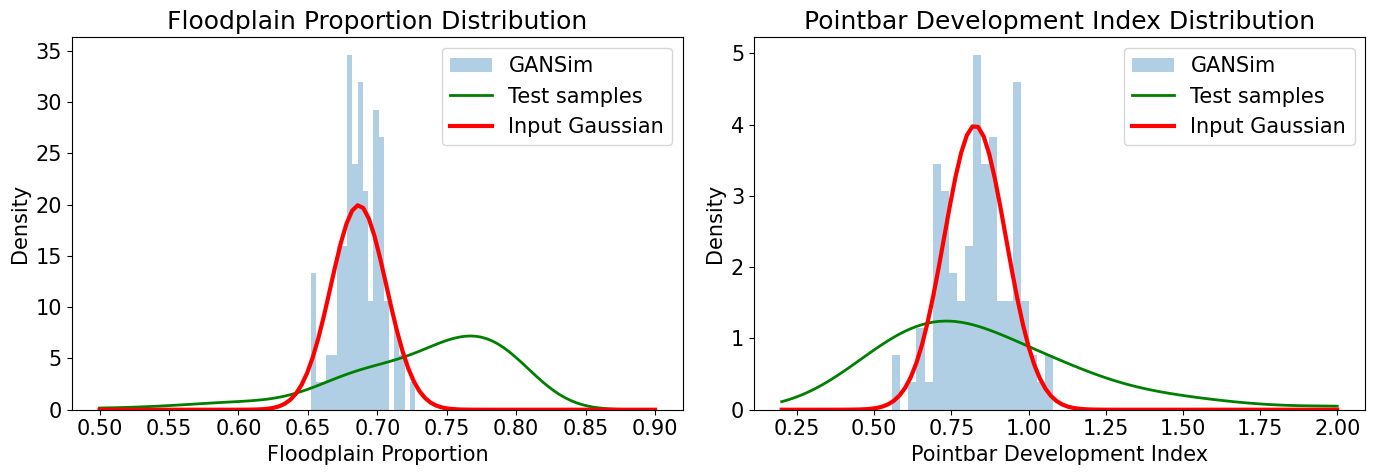

In [15]:
from scipy.stats import gaussian_kde, norm

plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- Left Plot: Floodplain Proportion ---
x_range_fp = np.linspace(0.5, 0.9, 100)
kde_fp_true = gaussian_kde(floodplain_prop_test, bw_method=0.4)
input_fp_pdf = norm.pdf(x_range_fp, loc=floodplain_prop_64, scale=floodplain_prop_var)

ax[0].hist(floodplain_prop_gansim, bins=20, density=True, alpha=0.35, label='GANSim')
ax[0].plot(x_range_fp, kde_fp_true(x_range_fp), color='green', linewidth=2, label='Test samples')
ax[0].plot(x_range_fp, input_fp_pdf, color='red', linewidth=3, label='Input Gaussian')
ax[0].set_xlabel('Floodplain Proportion')
ax[0].set_ylabel('Density')
ax[0].set_ylim(bottom=0)
ax[0].set_title('Floodplain Proportion Distribution')
ax[0].legend()

# --- Right Plot: Pointbar Development Index ---
x_range_pb = np.linspace(0.2, 2.0, 100)
kde_pb_true = gaussian_kde(pointbar_dev_test, bw_method=0.4)
input_pb_pdf = norm.pdf(x_range_pb, loc=pointbar_dev_64, scale=pointbar_dev_var)

ax[1].hist(pointbar_dev_gansim, bins=20, density=True, alpha=0.35, label='GANSim')
ax[1].plot(x_range_pb, kde_pb_true(x_range_pb), color='green', linewidth=2, label='Test samples')
ax[1].plot(x_range_pb, input_pb_pdf, color='red', linewidth=3, label='Input Gaussian')
ax[1].set_xlabel('Pointbar Development Index')
ax[1].set_ylabel('Density')
ax[1].set_ylim(bottom=0)
ax[1].set_title('Pointbar Development Index Distribution')
ax[1].legend()

plt.tight_layout()
plt.show()


**Gradually changing conditioning global features**

***Pointbar development index***

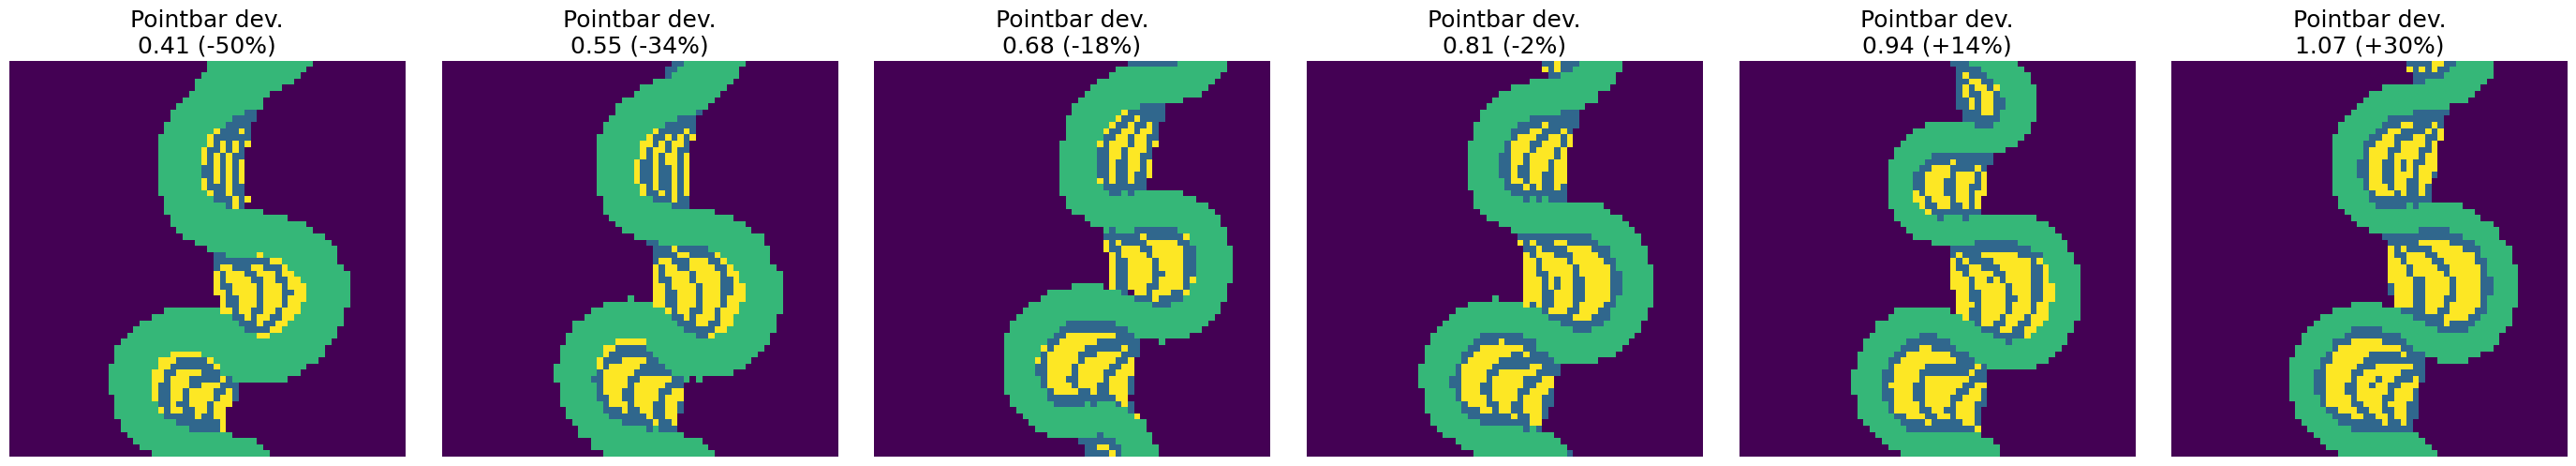

In [16]:
# Generate 6 realizations by varying the pointbar development index
# from -30% to +20% of the original value.
real_num = 6
# -??----------------------------------------------
# Hint: np.linspace(low, high, real_num)
pointbar_change_rates = np.linspace(-0.50, 0.30, real_num)
# -??----------------------------------------------
pointbar_dev_samples = pointbar_dev_64 * (1.0 + pointbar_change_rates)
floodplain_prop_samples = np.full(real_num, floodplain_prop_64, dtype=np.float32)

features_sampled_64 = np.stack([pointbar_dev_samples, floodplain_prop_samples], axis=1).astype(np.float32)

# -??----------------------------------------------
# Hint: run_gen_model(G=Generator, realization_number=realization_num, wells=wellfacies,
#                                        probs=probs, global_features=features, seed=seeds)
gen_model_indicators_64 = run_gen_model(G=G_64, realization_number=real_num, wells=wellfacies_64,
                                        probs=probs_64, global_features=features_sampled_64, seed=160)
# -??----------------------------------------------
gen_models_64 = np.expand_dims(np.argmax(gen_model_indicators_64, axis=1), axis=1)

plt.rcParams.update({'font.size': 20})
fig, axs = plt.subplots(1, 6, figsize=(28, 5))

for i in range(real_num):
    axs[i].imshow(gen_models_64[i, 0])
    axs[i].set_title(f"Pointbar dev.\n{pointbar_dev_samples[i]:.2f} ({pointbar_change_rates[i] * 100:+.0f}%)", fontsize=18)
    axs[i].axis('off')

plt.tight_layout()
plt.show()


***Floodplain proportion***


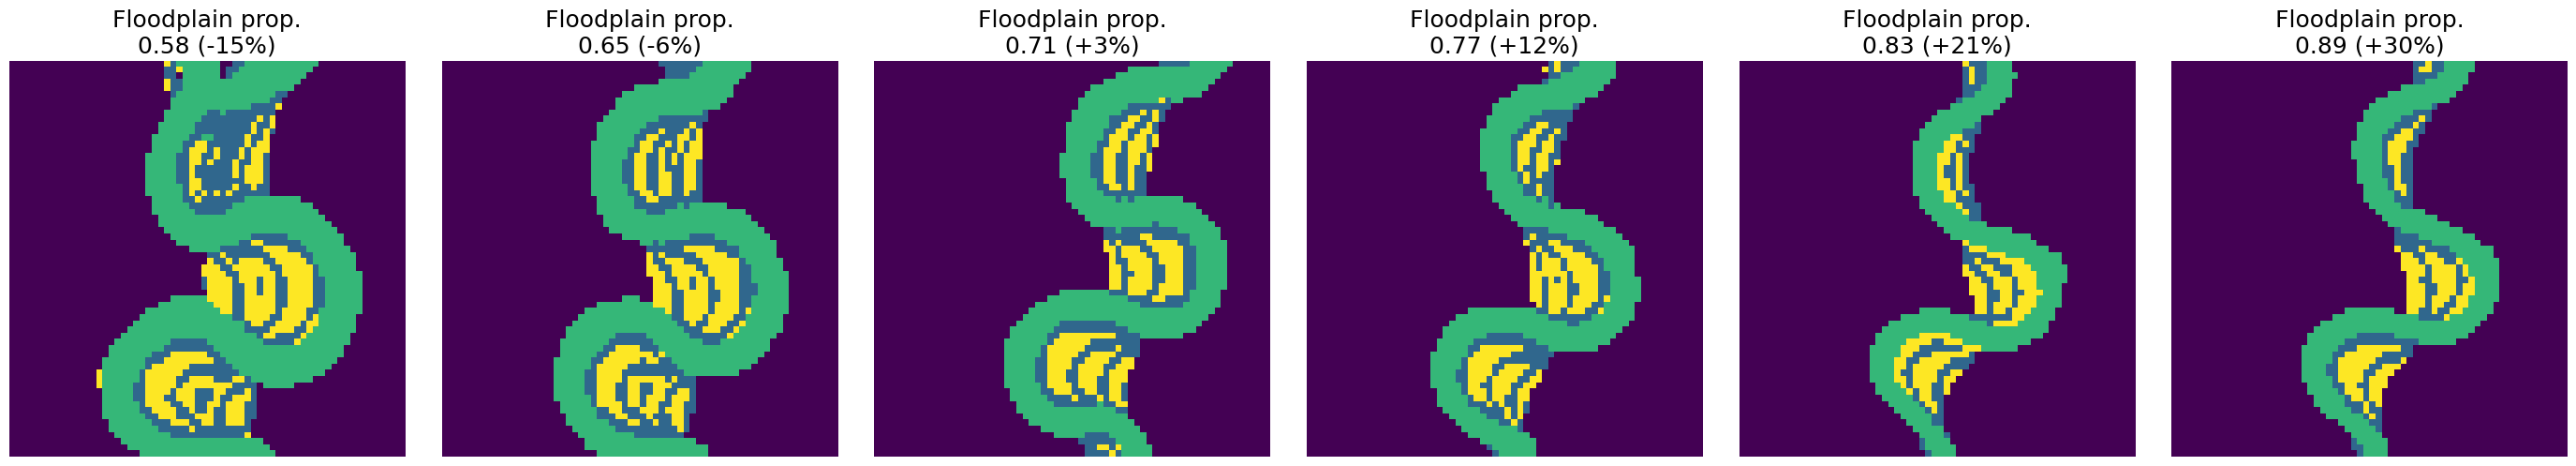

In [17]:
# Generate 6 realizations by varying the floodplain proportion
# from -30% to +20% of the original value.
real_num = 6
# -??----------------------------------------------
# Hint: np.linspace(low, high, real_num)
floodplain_change_rates = np.linspace(-0.15, 0.30, real_num)
# -??----------------------------------------------
floodplain_prop_samples = floodplain_prop_64 * (1.0 + floodplain_change_rates)
pointbar_dev_samples = np.full(real_num, pointbar_dev_64, dtype=np.float32)

features_sampled_64 = np.stack([pointbar_dev_samples, floodplain_prop_samples], axis=1).astype(np.float32)

gen_model_indicators_64 = run_gen_model(G=G_64, realization_number=real_num, wells=wellfacies_64, probs=probs_64, global_features=features_sampled_64, seed=160)
gen_models_64 = np.expand_dims(np.argmax(gen_model_indicators_64, axis=1), axis=1)

plt.rcParams.update({'font.size': 20})
fig, axs = plt.subplots(1, 6, figsize=(28, 5))

for i in range(real_num):
    axs[i].imshow(gen_models_64[i, 0])
    axs[i].set_title(f"Floodplain prop.\n{floodplain_prop_samples[i]:.2f} ({floodplain_change_rates[i] * 100:+.0f}%)", fontsize=18)
    axs[i].axis('off')

plt.tight_layout()
plt.show()


## 3. Conditional geomodelling for a large reservoir (192 × 192 cells)

Now, let us try a larger reservoir area of 1920 m × 1920 m, represented by `192 × 192` cells.

For demonstration, we use a large synthetic reference model as the hidden “truth.” We then sample consistent field conditioning data from it.


### 3.1 Building conditioning data

Conditioning data include:

- sparse **well facies** control points;
- smoothed/noisy **facies probability maps**; and
- **global geological features**, including pointbar development index and floodplain proportion.

In a real project, these conditioning data would come from real reservoirs.


In [19]:
TI_192_path = r'/content/GenAIGeomodeling/Data/GANSim_2DPointbar_Data_Model/TI_large/Unc_point_TI.npy'

truth = load_large_ground_truth(TI_192_path, output_size=(192, 192), case_index=0)
wells = sample_well_data(truth, n_wells=12, seed=143)
probs = generate_facies_probability_maps(geomodel_large_truth=truth, resolution_x=192,
                                         resolution_y=192, sigma=5, max_noise_size=6, seed=123)

# Calculate truth-level global feature values from the reference facies model.
truth_global_features = calculate_global_features(truth)
pointbar_dev = truth_global_features["pointbar_development_index"]
floodplain_prop = truth_global_features["floodplain_proportion"]

# Set uncertainty values for Gaussian sampling.
pointbar_dev_var = 0.10       # uncertainty/std for pointbar development index
floodplain_prop_var = 0.05    # uncertainty/std for floodplain proportion

print("Conditioning data shapes:")
print(f"  truth: {truth.shape}")
print(f"  wells: {wells.shape}")
print(f"  probs: {probs.shape}")

print("\nTruth-level global feature values and uncertainty settings:")
print("-" * 60)
print(f"Pointbar development index:")
print(f"  Truth value: {pointbar_dev:.4f}")
print(f"  Uncertainty std: {pointbar_dev_var:.4f}")
print(f"Floodplain proportion:")
print(f"  Truth value: {floodplain_prop:.4f}")
print(f"  Uncertainty std: {floodplain_prop_var:.4f}")
print("-" * 60)


0
Probability maps shape: (1, 3, 192, 192)
Conditioning data shapes:
  truth: (192, 192)
  wells: (2, 192, 192)
  probs: (1, 3, 192, 192)

Truth-level global feature values and uncertainty settings:
------------------------------------------------------------
Pointbar development index:
  Truth value: 0.5261
  Uncertainty std: 0.1000
Floodplain proportion:
  Truth value: 0.7413
  Uncertainty std: 0.0500
------------------------------------------------------------


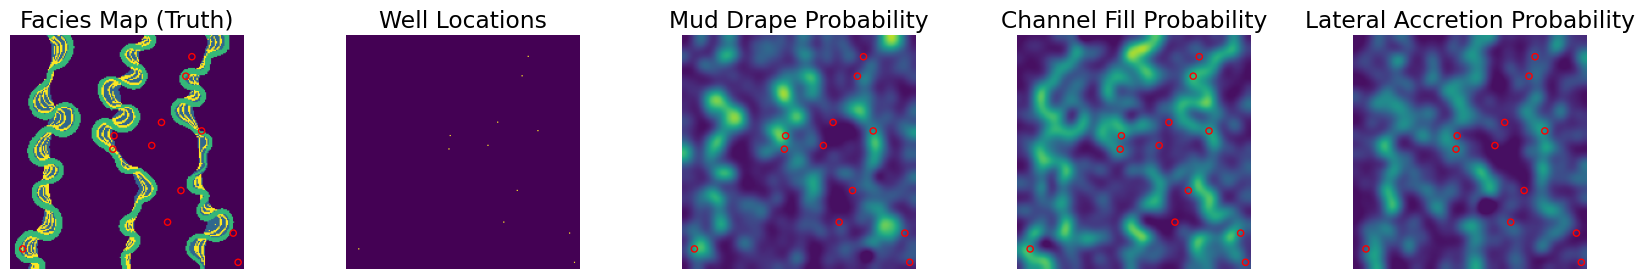

In [20]:
plt.rcParams.update({'font.size': 14})

truth_map = truth
well_loc = wells[0]
mud_prob = probs[0, 0]
cf_prob = probs[0, 1]
la_prob = probs[0, 2]

well_y, well_x = np.where(well_loc > 0)

fig, ax = plt.subplots(1, 5)
fig.set_size_inches(17, 3, forward=True)

ax[0].imshow(truth_map.astype(np.float32))
ax[0].scatter(well_x, well_y, s=20, marker='o', facecolor='none', edgecolor='red')
ax[0].set_title('Facies Map (Truth)')
ax[0].axis('off')

ax[1].imshow(well_loc.astype(np.float32), vmin=0, vmax=1)
ax[1].set_title('Well Locations')
ax[1].axis('off')

ax[2].imshow(mud_prob.astype(np.float32), vmin=0, vmax=0.5)
ax[2].scatter(well_x, well_y, s=20, marker='o', facecolor='none', edgecolor='red')
ax[2].set_title('Mud Drape Probability')
ax[2].axis('off')

ax[3].imshow(cf_prob.astype(np.float32), vmin=0, vmax=0.5)
ax[3].scatter(well_x, well_y, s=20, marker='o', facecolor='none', edgecolor='red')
ax[3].set_title('Channel Fill Probability')
ax[3].axis('off')

ax[4].imshow(la_prob.astype(np.float32), vmin=0, vmax=0.5)
ax[4].scatter(well_x, well_y, s=20, marker='o', facecolor='none', edgecolor='red')
ax[4].set_title('Lateral Accretion Probability')
ax[4].axis('off')

plt.tight_layout()
plt.show()


### 3.1 Conditional geomodelling with the generator given conditioning data

In [21]:
G_192 = build_generator_for_reservoir(G_base, nx = 192, ny = 192, network_name = "Gs_for_192x192")

Generator rebuilt for reservoir size.
  Reservoir size: 192 x 192
  Input shapes: [[Dimension(None), Dimension(8), Dimension(12), Dimension(12)], [Dimension(None), Dimension(2), Dimension(192), Dimension(192)], [Dimension(None), Dimension(2), Dimension(192), Dimension(192)], [Dimension(None), Dimension(3), Dimension(192), Dimension(192)]]
  Output shapes: [[Dimension(None), Dimension(4), Dimension(192), Dimension(192)]]


In [22]:
real_num = 100  # Number of realizations to simulate

# Randomly sample global features using Gaussian distributions.
pointbar_dev_samples = np.random.normal(loc=pointbar_dev, scale=pointbar_dev_var, size=real_num)
floodplain_prop_samples = np.random.normal(loc=floodplain_prop, scale=floodplain_prop_var, size=real_num)
# Stack sampled global features. Shape: [real_num, 2]
sampled_global_features = np.stack([pointbar_dev_samples, floodplain_prop_samples], axis=1).astype(np.float32)

# Generate facies indicator maps.
gen_model_indicators_192 = run_gen_model(G=G_192, realization_number=real_num, wells=wells,
                                         probs=probs, global_features=sampled_global_features, seed=160)

# Convert facies indicators into facies-code models.
gen_models_192 = np.expand_dims(np.argmax(gen_model_indicators_192, axis=1), axis=1)


Plot random realizations and frequency maps for mud drape, channel fill, and lateral accretion

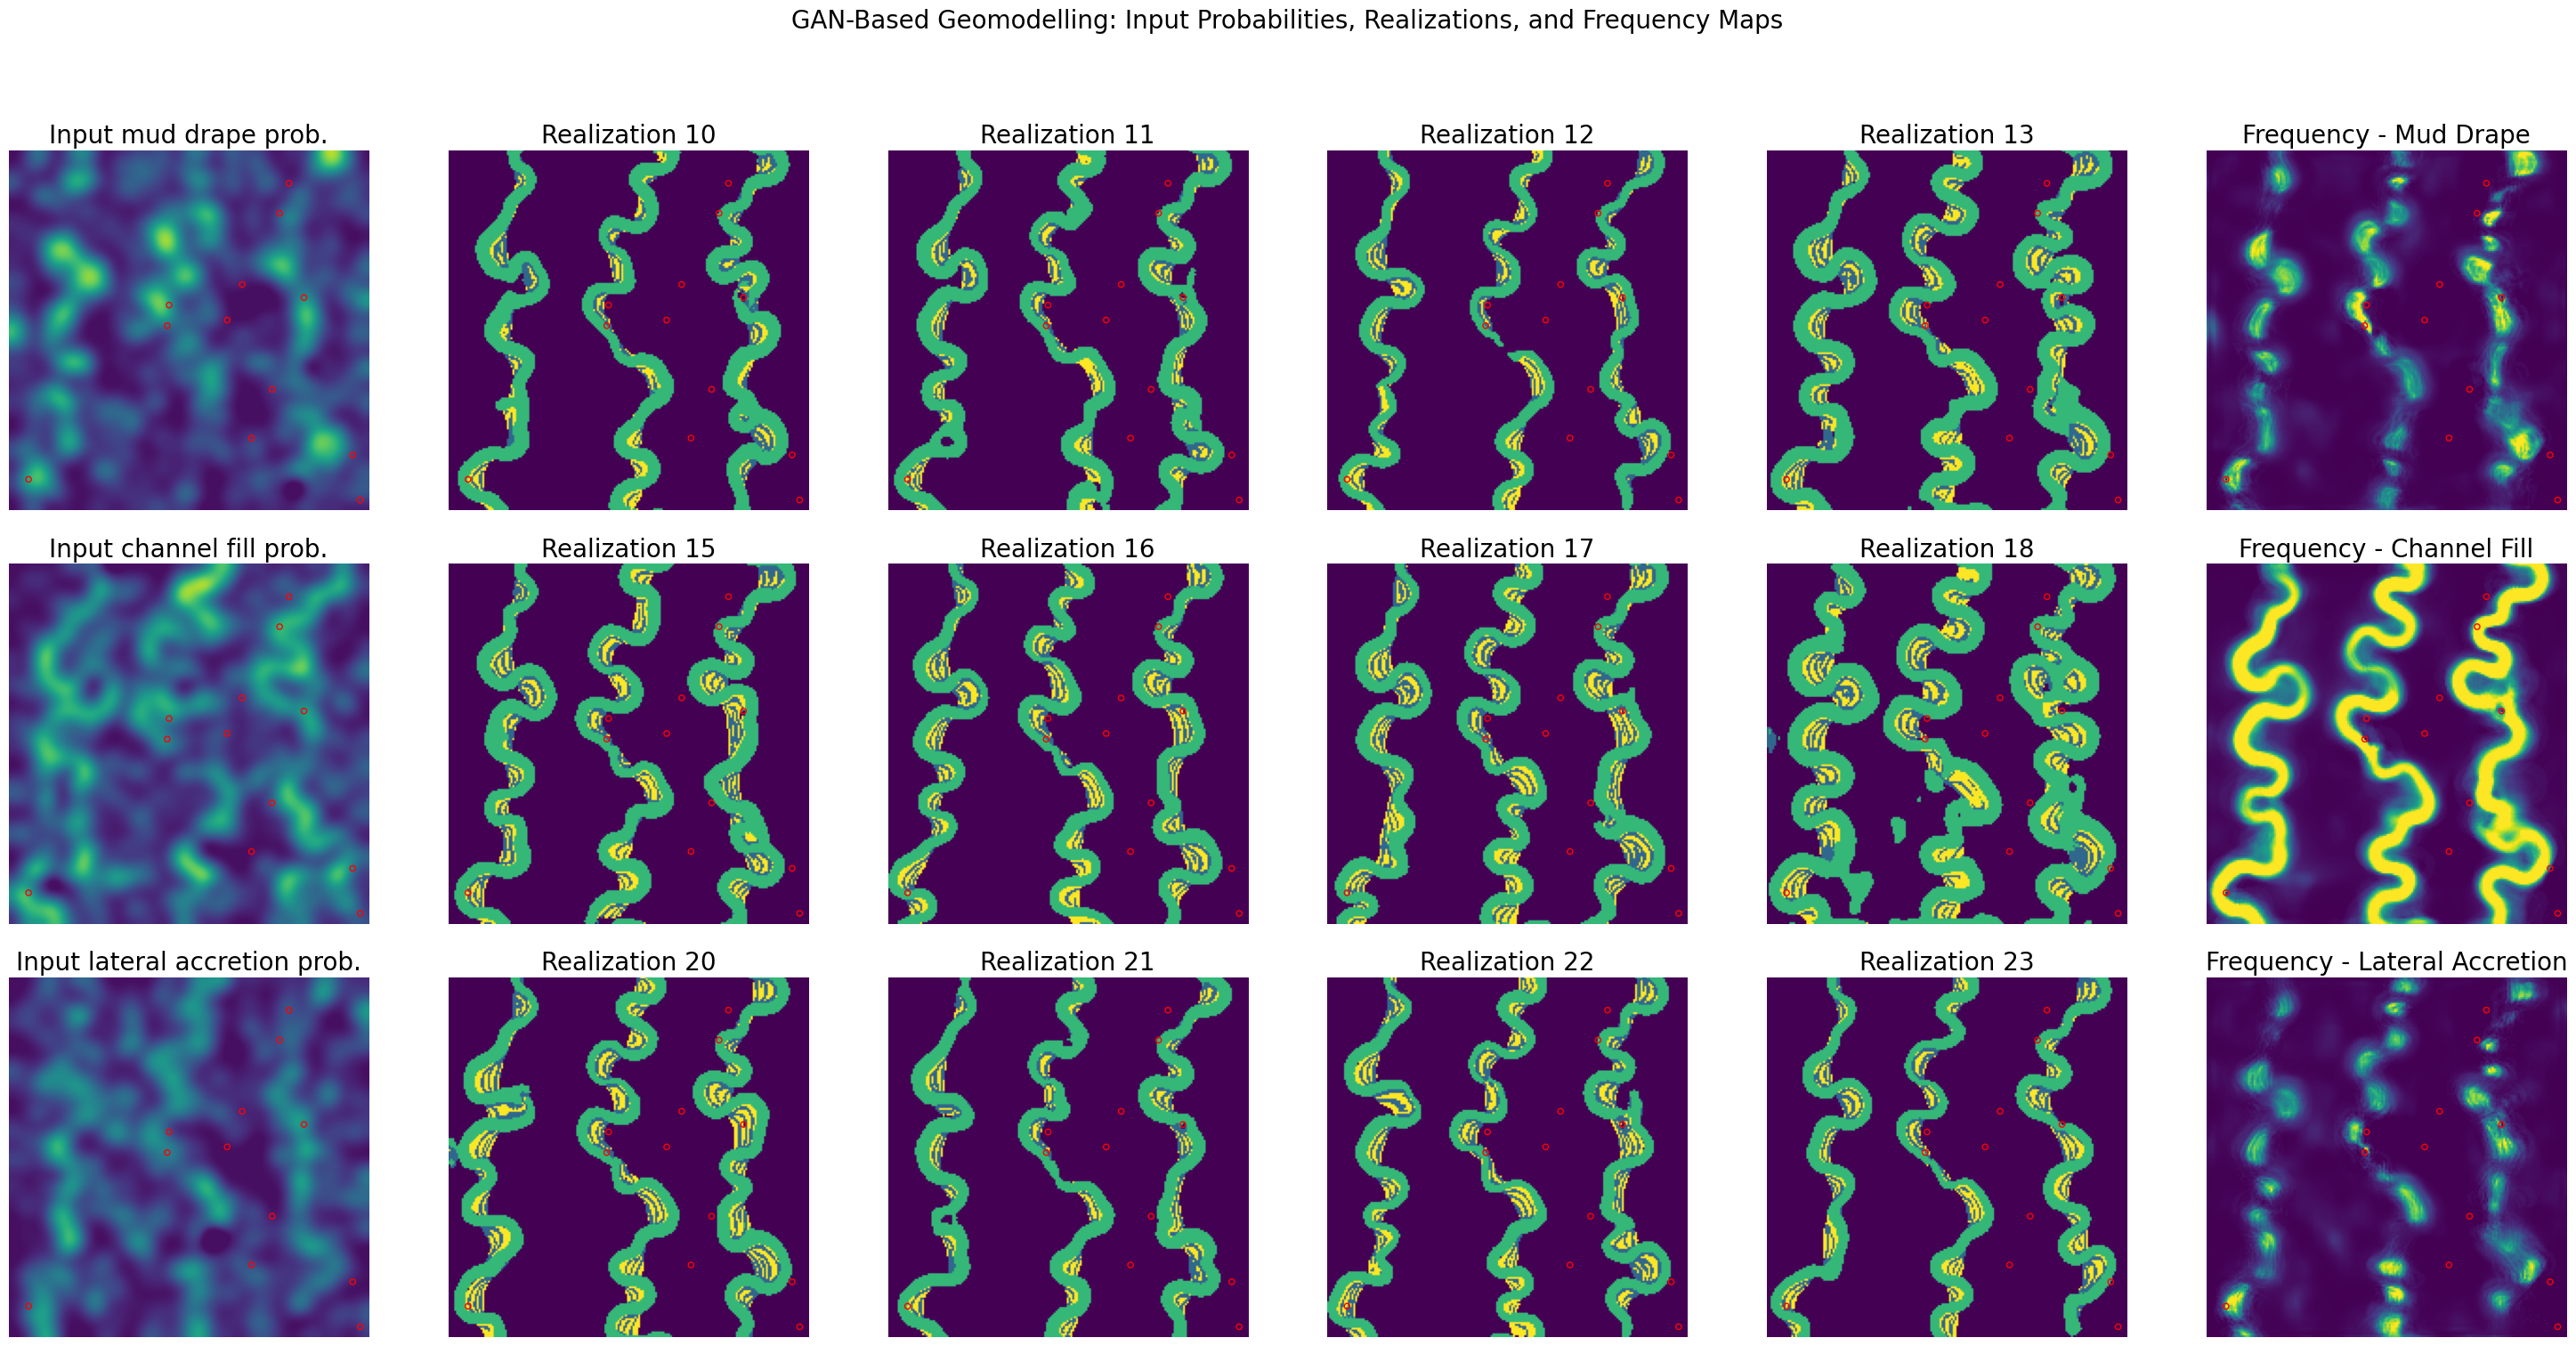

In [23]:
plt.rcParams.update({'font.size': 25})

# Calculate frequency maps from generated facies indicator maps.
gen_model_freq_md = np.average(gen_model_indicators_192[:, 1], axis=0)
gen_model_freq_cf = np.average(gen_model_indicators_192[:, 2], axis=0)
gen_model_freq_la = np.average(gen_model_indicators_192[:, 3], axis=0)

fig, ax = plt.subplots(3, 6, sharex='col', sharey='row')
fig.set_size_inches(30, 15, forward=True)

# Plot input probability maps.
ax[0, 0].imshow(probs[0, 0].astype(np.float32), cmap='viridis', vmin=0, vmax=0.5)
ax[0, 0].set_title("Input mud drape prob.", fontsize=20)

ax[1, 0].imshow(probs[0, 1].astype(np.float32), cmap='viridis', vmin=0, vmax=0.5)
ax[1, 0].set_title("Input channel fill prob.", fontsize=20)

ax[2, 0].imshow(probs[0, 2].astype(np.float32), cmap='viridis', vmin=0, vmax=0.5)
ax[2, 0].set_title("Input lateral accretion prob.", fontsize=20)

# Plot 4 sample realization columns.
for i in range(3):
    for j in range(1, 5):
        idx = i * 5 + j - 1 + 10
        ax[i, j].imshow(gen_models_192[idx, 0])
        ax[i, j].set_title(f"Realization {idx}", fontsize=20)

# Plot frequency maps in the final column.
ax[0, 5].imshow(gen_model_freq_md, vmin=0, vmax=0.5)
ax[0, 5].set_title("Frequency - Mud Drape", fontsize=20)

ax[1, 5].imshow(gen_model_freq_cf, vmin=0, vmax=0.5)
ax[1, 5].set_title("Frequency - Channel Fill", fontsize=20)

ax[2, 5].imshow(gen_model_freq_la, vmin=0, vmax=0.5)
ax[2, 5].set_title("Frequency - Lateral Accretion", fontsize=20)

# Plot well locations in red circles.
index_x = np.argwhere(wells[0] > 0)[:, 1]
index_y = np.argwhere(wells[0] > 0)[:, 0]

for i in range(3):
    for j in range(6):
        ax[i, j].scatter(index_x, index_y, s=20, marker='o', facecolor='none', edgecolor='red')
        ax[i, j].axis('off')

fig.suptitle("GAN-Based Geomodelling: Input Probabilities, Realizations, and Frequency Maps", fontsize=20, y=1.02)

plt.tight_layout()
plt.show()


Well facies reproduction accuracy

In [24]:
well_acc = calc_well_conditioning_accuracy(facies_models=gen_models_192, wells=wells)
print(f"Well conditioning accuracy: {well_acc * 100:.1f}%")


Well conditioning accuracy: 100.0%


### 3.3 Nonstationary geomodelling from spatially varying global features

A key practical advantage is that a generator trained on stationary patches can still create nonstationary field-scale models when the conditioning inputs vary spatially.

Here, we create spatial trends in the two global-feature maps to mimic changing depositional style across the field.


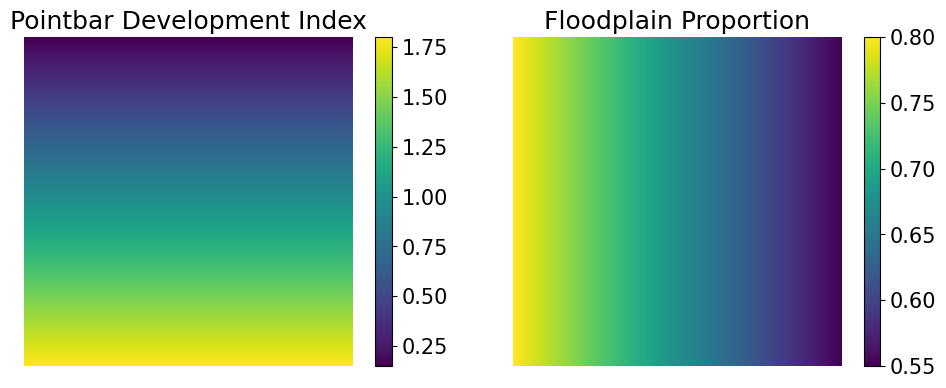

In [25]:
# pointbar development index: full range 0.2-2.0
pointbar_dev_min = 0.15
pointbar_dev_max = 1.80
pointbar_dev_map = make_one_spatial_feature_map(output_size=(192, 192), vmin=pointbar_dev_min,
                                                vmax=pointbar_dev_max, trend="north_to_south")

# floodplain proportion: full range 0.5-0.85
floodplain_prop_min = 0.55
floodplain_prop_max = 0.80
floodplain_prop_map = make_one_spatial_feature_map(output_size=(192, 192), vmin=floodplain_prop_min,
                                                   vmax=floodplain_prop_max, trend="east_to_west")
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
im0 = ax[0].imshow(pointbar_dev_map, vmin=pointbar_dev_min, vmax=pointbar_dev_max)
ax[0].set_title("Pointbar Development Index")
ax[0].axis("off")
fig.colorbar(im0, ax=ax[0])

im1 = ax[1].imshow(floodplain_prop_map, vmin=floodplain_prop_min, vmax=floodplain_prop_max)
ax[1].set_title("Floodplain Proportion")
ax[1].axis("off")
fig.colorbar(im1, ax=ax[1])

plt.tight_layout()
plt.show()


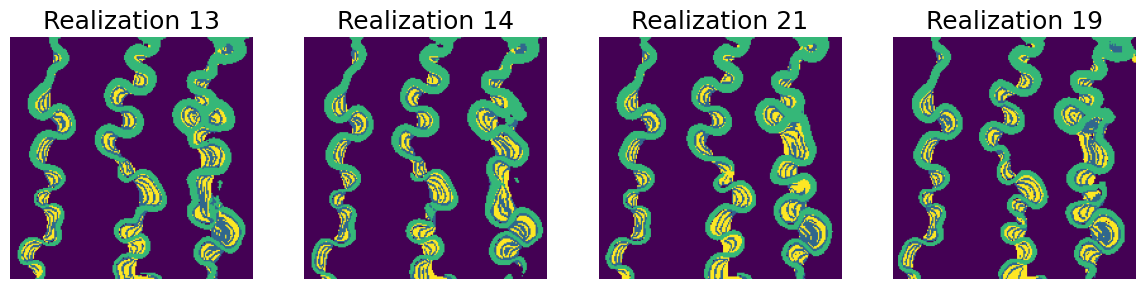

In [26]:
# Stack the two spatial feature maps. Shape: [realization_number, 2, nx, ny]
nonstationary_features = np.concatenate([pointbar_dev_map[None, None],
                                         floodplain_prop_map[None, None]], axis=1).astype(np.float32)

gen_model_indicators_nonst_192 = run_gen_model(G=G_192, realization_number=25, wells=wells, probs=probs, global_features=nonstationary_features, seed=200)
gen_models_nonst_192 = np.expand_dims(np.argmax(gen_model_indicators_nonst_192, axis=1), axis=1)

idx = np.random.choice(gen_models_nonst_192.shape[0], 4, replace=False)

fig, ax = plt.subplots(1, 4, figsize=(12, 3))

for i in range(4):
    ax[i].imshow(gen_models_nonst_192[idx[i], 0])
    ax[i].set_title(f"Realization {idx[i]}")
    ax[i].axis("off")

plt.tight_layout()
plt.show()
